# Shunique - Company Background
Shunique is a hot new online women's shoe company that is known for their unique shoe combinations.  Founded by auto tire amgnate Joseph Flatbush and his daugthers Jenna and Jamaica.  He believed that just like car tires, women's shoes should be unique and stylish. However, a bold choice to release a "silver vegan leather sandal" that had very few sales has left the company to turn towards their data in search of the next big shoe hit.  The company doesn't know much about their data and have not been keeping up with their monthly, quarterly, and yearly performance.    You were hired as a data analyst to help them answer key questions.  You were given all the shoe sales transactions from Aug 2018 to Aug 2020.  They do know a few statistics:  (1) They have generated \$166,936,995 in total sales since opening (2) The top 3 cities for number of shoes sold are Washington, DC, Houston, Tx, and El Paso, Tx (See Figure below).  They have also provided you with a codebook describing all the columns and their potential values.
<img src="num_shoes_sold_per_city.png">

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
sales = pd.read_csv('transactions.csv')
#full transactions.csv dataset has been omitted from repository due to file sizing constraints

## Question 1

**(1a.)** what was the name of the Best selling shoe and total sales for the Second Fiscal Quarter(Q2) of 2020?

**Answer:** Mirak Womens 12482-18788 Khaki Lace Up Waterproof Walking Boot 3

**(1b)**. How did it compare to that shoe's sales in 2019 Q2?  Is it the hottest selling shoe in Q2 2019?  What else can you say about the Q2 2019 versus Q2 2020 performance of this shoe relative to other top sellers during these quarters?  

**Answer:** The Mirak Womens 12482-18788 Khaki Lace Up Waterproof Walking Boot 3 was the third best selling shoe in 2019 with total sales of 102,480, which is the same sales revenue as in Q2 2020. Furthermore, in 2019 this shoe was one of three shoes that had over 100k of sales, which was significantly higher than the fourth best-selling shoe that year. However in 2020, this shoe was the only shoe with over 100k of sales, with the next best-selling shoe having 690k of sales.

**Definition of Quarters:**
January, February, and March (Q1)
April, May, and June (Q2)
July, August, and September (Q3)
October, November, and December (Q4) 

In [2]:
sales['Date'] = pd.to_datetime(sales['Date'])
#sales_date=sales.set_index('Date')

Q2_2020 = sales[(sales['Date'] >= '2020-4-1') & (sales['Date'] <= '2020-6-30')]
Q2_2020_sales = Q2_2020.groupby('name')['cost'].sum().sort_values(ascending=False)[:5]

Q2_2020_sales

name
Mirak Womens 12482-18788 Khaki Lace Up Waterproof Walking Boot 3                 102480.00
Yu&yu Women's Shoes Round Toe Chunky Heel Oxfords Shoes More Colors Available     69030.60
Diamond Eternity Band                                                             62984.85
Yu&yu Women's Shoes Pointed Toe Flat Heel Flats Shoes More Colors Available       54738.24
Yu&yu Women's Shoes Round Toe Low Heel Oxfords Shoes More Colors Available        45935.19
Name: cost, dtype: float64

In [3]:
Q2_2019 = sales[(sales['Date'] >= '2019-4-1') & (sales['Date'] <= '2019-6-30')]
Q2_2019_sales = Q2_2019.groupby('name')['cost'].sum().nlargest(5)

Q2_2019_sales

name
Diamond Eternity Band                                                            138566.67
Yu&yu Women's Shoes Round Toe Chunky Heel Oxfords Shoes More Colors Available    133459.16
Mirak Womens 12482-18788 Khaki Lace Up Waterproof Walking Boot 3                 102480.00
Yu&yu Women's Shoes Round Toe Low Heel Oxfords Shoes More Colors Available        74371.26
'pebbles' Tall Gladiator Pump (women)                                             59800.00
Name: cost, dtype: float64

## Question 2

Over the life of the collected data,

**(2a)** What state has the highest total sales?  **Answer:** Texas

**(2b)** Which state/district/terrritory sold the most shoes over this same period?  **Answer:** Texas

**(2c)** Which state/district/terrritory sold the least number of shoes over this period? **Answer:** DC

In [4]:
sales_states_2a = sales.groupby(by='state').sum(numeric_only=True).sort_values('cost', ascending=False)[:3]

sales_states_2a

,quantity,prices,cost
state,,,
Texas,43399,2534360.26,4046697.79
California,42987,2549023.99,4040519.98
Florida,40655,2439983.57,3915786.35


In [5]:
sales_states_2b = sales.groupby(by='state').sum(numeric_only=True).sort_values('quantity', ascending=False)[:3]

sales_states_2b

,quantity,prices,cost
state,,,
Texas,43399,2534360.26,4046697.79
California,42987,2549023.99,4040519.98
Florida,40655,2439983.57,3915786.35


In [6]:
sales_states_2c = sales.groupby(by='state').sum(numeric_only=True).sort_values('quantity', ascending=True)[:3]

sales_states_2c

,quantity,prices,cost
state,,,
District of Columbia,2770,156416.91,256872.67
Wyoming,33244,1995366.07,3157960.68
Hawaii,33382,1953617.98,3103894.39


## Question 3
Jenna Flatbush wants to know what combination of shoes to introduce into low-performing cities.  You came up with the idea that they should start marketing combinations that are already selling well.

**(3.)** What combination of attributes have the most sales? [ color, materials, feature, category ] **Answer:** black leather travel friendly wedges

In [7]:
sales['shoe_combo'] = sales['color'] + ' ' + sales['materials'] + ' ' + sales['feature'] + ' ' + sales['category']
sales.groupby('shoe_combo')['cost'].sum().sort_values(ascending=False)[:3]

shoe_combo
black leather travel friendly wedges     881131.43
black rubber diabetic approved wedges    713090.00
black leather padding heels              523562.83
Name: cost, dtype: float64

## Question 4

Jamaica Flatbush is unsure of how Shunique performed last year (2019). 

**(4a)** What were total sales? **Answer:** \$87,005,120

**(4b)** Plot daily, monthly, quarterly sales for 2019. 

**(4c)** Are there any trends? 

**Answer:** Yes - it looks like the sales are largely consistent throughout the year until Q4. In October the sales increase and it stays consitent through December. 

**(4d)** In the monthly sales data, describe a significant event (ie. increase or decrease in sales) and hypothesize(make a wild guest) about its existence? What additional evidence(data) would be needed to support or negate your hypothesis.

**Answer:** It's possible that in October people begin to shop for the holidays and therefore sales increase. To support this hypothesis, it would be helpful to know if they conduct any consumer surveys and those responses, as well as web traffic/foot traffic if they have physical stores. It would also be good to know if the company has sales during this time of year that drive people to the store.

In [8]:
sales_2019 = sales[sales['Date'].dt.year==2019].set_index('Date')
sales_2019['cost'].sum()


87005120.81000003

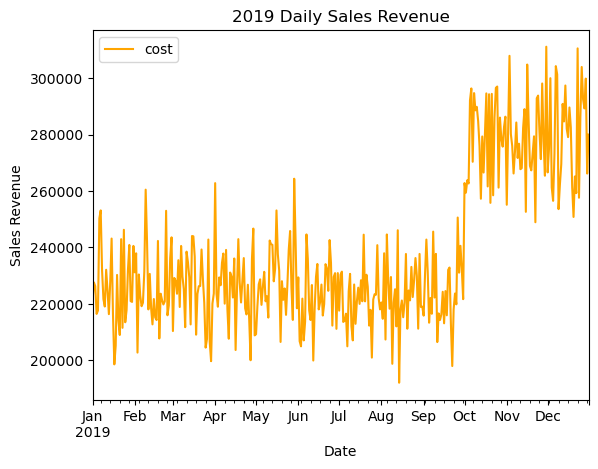

In [9]:
sales_2019.groupby(pd.Grouper(freq="D"))[['cost']].sum().plot.line(color="orange")

plt.title('2019 Daily Sales Revenue')
plt.xlabel('Date')
#plt.xticks(rotation=90, ha="right")
plt.ylabel('Sales Revenue')

plt.show();

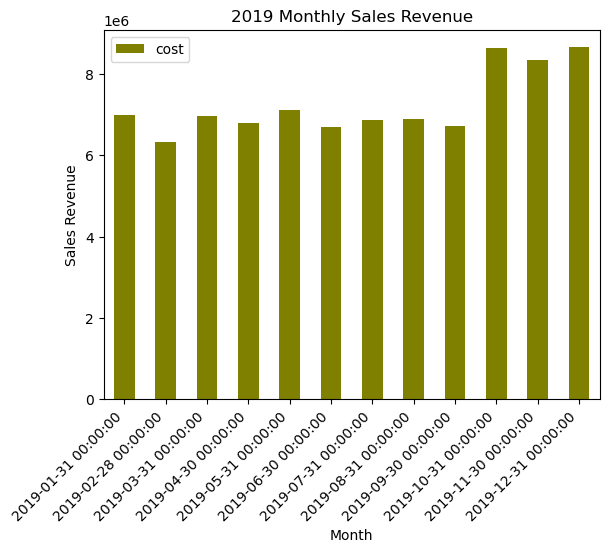

In [10]:
sales_2019.groupby(pd.Grouper(freq="ME"))[['cost']].sum().plot.bar(color="olive")

plt.title('2019 Monthly Sales Revenue')
plt.xlabel('Month')
plt.xticks(rotation=45, ha="right")
plt.ylabel('Sales Revenue')

plt.show();

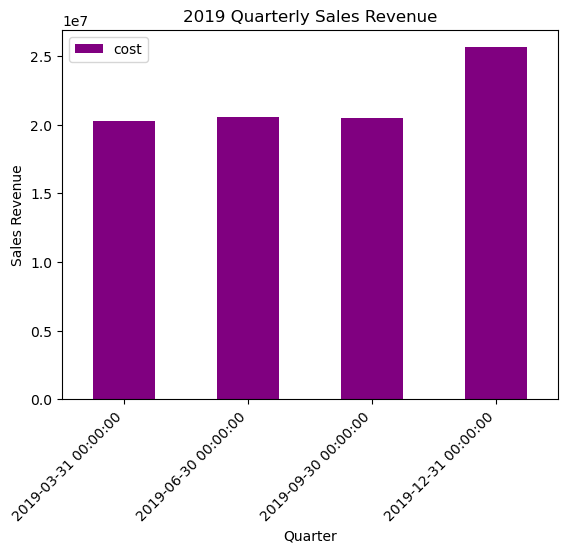

In [11]:
sales_2019.groupby(pd.Grouper(freq="QE"))[['cost']].sum().plot.bar(color="purple")

plt.title('2019 Quarterly Sales Revenue')
plt.xlabel('Quarter')
plt.xticks(rotation=45, ha="right")
plt.ylabel('Sales Revenue')

plt.show();

## Question 5

A key metric for retail sales data is Average Purchase Value(APV).  APV measures the average value of each purchase made by your customers and will often compare that to the average number of units per transaction(ANU). The formula for APV is (Total Sales Revenue / Number of Customers or Transactions)

**(5a).** Calculate the Average Purchase Value for Q1 and Q4 of 2019. **Answer:** Q1: \$146 ; Q4: \$182

**(5b).** Calculate the average number of units per transaction for Q1 and Q4 **Answer:** Q1: 1.5 ; Q4: 1.9

**(5c).** Describe the differences between Q1 and Q4 values.  Speculate on possible causes for differences(Hint: Seasonality)

**Answer:** the APV and ANU in A4 are greater than in Q1. This could be due to higher sales during the holidays at the end of the year.

In [12]:
sales_2019.groupby(pd.Grouper(freq="QE"))[['cost']].mean()

,cost
Date,
2019-03-31,146.753293
2019-06-30,147.057139
2019-09-30,146.103229
2019-12-31,182.455939


In [13]:
sales_2019.groupby(pd.Grouper(freq="QE"))[['quantity']].mean()

,quantity
Date,
2019-03-31,1.548540
2019-06-30,1.550076
2019-09-30,1.548482
2019-12-31,1.903052


## Question 6

Shunique is looking to expand its distribution centers so that it can outperform Zappos on delivery time to customers.  It is important to know what states and regions are epicenters for high sales and you have been asked to present the following results.

**(6a)** Report 2020 Sales by state - Present results tabularly 

**(6b)** In Tableau create a Map visualization of total sales(2018 - 2020) by Region [Northeast, West, Midwest, South].

In [14]:
sales_2020 = sales[sales['Date'].dt.year==2020].set_index('Date')
sales_state_2020 = sales_2020.groupby('state')['cost'].sum().sort_values(ascending=False)

sales_state_2020

state
Texas                   1238215.58
California              1219721.54
Florida                 1143359.72
New York                1074477.72
Ohio                    1021461.58
Virginia                1009027.82
Oklahoma                 996220.92
Washington               994863.51
Georgia                  988708.06
Indiana                  980345.53
Pennsylvania             979018.40
Alabama                  974686.32
Illinois                 974058.97
Louisiana                965760.25
Nevada                   965571.65
Tennessee                962034.79
Minnesota                960446.90
Wisconsin                960293.69
North Carolina           959069.53
Iowa                     958326.67
West Virginia            956208.75
Michigan                 955762.10
New Jersey               949132.92
Arkansas                 945093.20
New Mexico               941271.88
Massachusetts            941206.10
Colorado                 941015.24
Utah                     939794.05
Connecticut   

Map of sales by region:

<img src="Sales_by_region.png">

## Question 7

Use any type of plot to show the distribution of prices for the following shoe colors ('metallic', 'bronze', 'animal print', 'yellow')

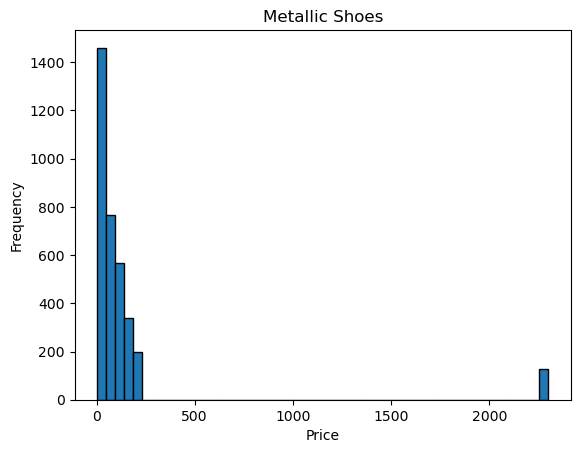

In [15]:
sales[sales['color']=='metallic']['prices'].plot.hist(bins=50, edgecolor='k')

plt.title('Metallic Shoes')
plt.xlabel('Price')

plt.show()

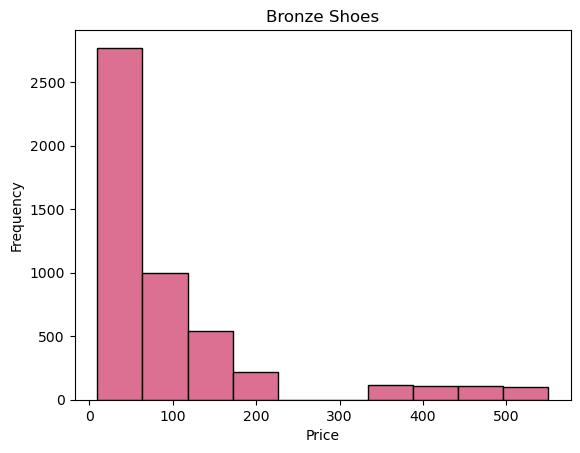

In [16]:
sales[sales['color']=='bronze']['prices'].plot.hist(bins=10, edgecolor='k', color = 'palevioletred')

plt.title('Bronze Shoes')
plt.xlabel('Price')

plt.show()

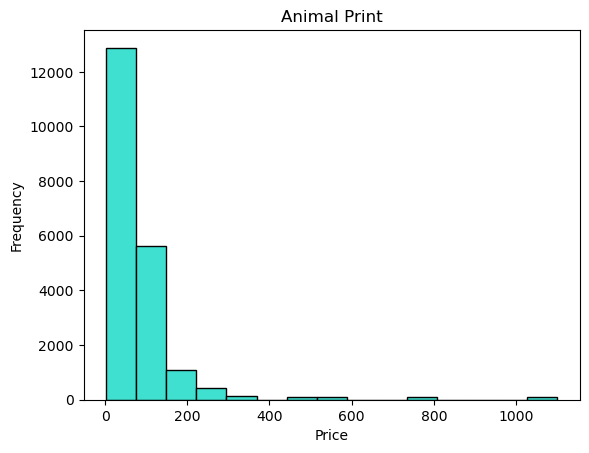

In [17]:
sales[sales['color']=='animal print']['prices'].plot.hist(bins=15, edgecolor='k', color = 'turquoise')

plt.title('Animal Print')
plt.xlabel('Price')

plt.show()

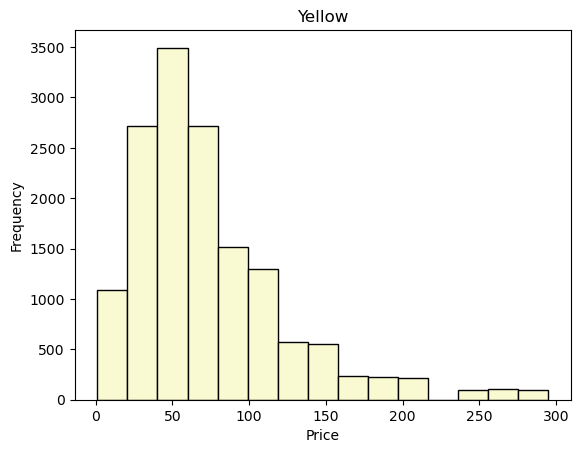

In [18]:
sales[sales['color']=='yellow']['prices'].plot.hist(bins=15, edgecolor='k', color = 'lightgoldenrodyellow')

plt.title('Yellow')
plt.xlabel('Price')

plt.show()

## Question 8

The Shunique marketing team is desperate to find the next big shoe hit.  They have asked for your help. 

**(8a)** Select a unique combination of shoe attributes then create a summary report with various statistics (ie Average sales price, city with most sales, quarter with most shoes sold, Customer name with highest purchase, etc)[it is your choice].  If the shoe combo doesn't exist in the dataset then choose another combination.

**Answer:** The average salse price of the animal print leather strappy basketball shoe from 2018 to 2020 was \$69.96. The city with the most sales during this time period was tied between Brianbury, East Michaelside, Elizabethshire, New Matthew, North Victorstad, and West Nichole - each with \$279 of sales. The quarter with the most shoes sold was Q4 2019 with a total sales of \$267,415. The customers who purchased the most of this shoe are Jennifer Davis, Timothy Montoya, Matthew Brooks, Cameron Perez, Joshua Munoz, and Natalie Kelley - all of whom purchased 4 pairs of the shoe.

Next quarter they are going to release an animal print, leather, strappy, basketball shoe.  

In [19]:
#nbs stands for next big shoe
nbs = sales[sales['shoe_combo']=='animal print leather strappy basketball']

nbs.groupby('shoe_combo')['prices'].mean()

shoe_combo
animal print leather strappy basketball    69.96
Name: prices, dtype: float64

In [20]:
nbs.groupby('city')['cost'].sum().nlargest(10)

city
Brianbury           279.84
East Michaelside    279.84
Elizabethshire      279.84
New Matthew         279.84
North Victorstad    279.84
West Nichole        279.84
East Misty          209.88
Gilbertstad         209.88
Johnsonside         209.88
Lake Adam           209.88
Name: cost, dtype: float64

In [21]:
nbs_quarterly = sales.set_index('Date')
nbs_quarterly.groupby(pd.Grouper(freq='QE'))['quantity'].sum().sort_values(ascending=False)[:5]

Date
2019-12-31    267415
2019-09-30    217139
2019-06-30    216944
2020-03-31    216944
2020-06-30    214681
Name: quantity, dtype: int64

In [22]:
nbs['full_name'] = nbs['first_name'] + ' ' + nbs['last_name']
nbs.groupby('full_name')['quantity'].sum().sort_values(ascending=False)[:10]

/var/folders/l0/_38t32yn4bn0v_vqm1gmxqkh0000gn/T/ipykernel_3621/2202910884.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nbs['full_name'] = nbs['first_name'] + ' ' + nbs['last_name']


full_name
Jennifer Davis      4
Timothy Montoya     4
Mathew Brooks       4
Cameron Perez       4
Joshua Munoz        4
Natalie Kelley      4
Elizabeth Branch    3
Leora Stratz        3
Natalie Wells       3
Phillip Crawford    3
Name: quantity, dtype: int64

## Question 9

**(9a)** Are there opportunities to grow sales?  **Answer:** New York and DC are in the same northeast region, but DC is the jurisdiction with the lowest sales. The company could look at the shoes that are doing the best in New York (like Mirak Womens 12482-18788 Khaki Lace Up Waterproof Walking Boot 3) and market them more heavily in DC to attempt to boost sales in the city. 

**(9b)** Are there products that you would discontinue? **Answer:** The company can consider discontinuing the sale of the shoes that made less than $100 of income (Guess Ortena2 Bronze/black Ankle Booties Boots Size 6.5 to Nina Falana-vg Women Us 6 Silver Sandals Pre Owned 1904 ).

**(9c)** What other datasets would you use to complement the transaction data and why? It would be helpful to have data on labor costs as it would provide insight to how expensive it actually is to make a shoe. 

In [23]:
sales[sales['state'] == 'New York'].groupby(by = ['name'])['cost'].sum(numeric_only=True).sort_values(ascending = False)[:5]

name
Mirak Womens 12482-18788 Khaki Lace Up Waterproof Walking Boot 3               29890.00
Diamond Eternity Band                                                          20994.95
'pebbles' Tall Gladiator Pump (women)                                          16100.00
'rockstud' Sandal                                                              12540.00
Yu&yu Women's Shoes Pointed Toe Flat Heel Flats Shoes More Colors Available    11973.99
Name: cost, dtype: float64

In [24]:
sales[sales['state'] == 'District of Columbia'].groupby(by = ['name'])['cost'].sum(numeric_only=True).sort_values(ascending = False)[:5]

name
Metallic Lace-up Oxford (women)      4480.0
Geometric Block Heel Pump (women)    4170.0
Suede Taci Ii Boot                   3900.0
Sacha Calfskin Boot                  2200.0
Side Zip Sneaker (women)             1995.0
Name: cost, dtype: float64

In [25]:
sales_name_2020 = sales_2020.groupby('name')['cost'].sum().sort_values(ascending=True)[:15]
sales_name_2020

name
Guess Ortena2 Bronze/black Ankle Booties Boots Size 6.5                               0.62
Bcbgeneration Anais Women Us 6.5 Tan Thong Sandal Pre Owned Blemish 1665             36.63
Bella Vita Sangria Women Us 7.5 N/s White Wedge Sandal Blemish 1903                  38.61
Alfani Hannia Women Us 8.5 Gold Thong Sandal Pre Owned 1904                          39.60
Mix No 6 Sarti Women Us 8 Green Platform Heel Pre Owned 1650                         40.59
Bandolino Adecyn Women Us 7 Black Wedge Sandal Pre Owned 1904                        44.55
Kenneth Cole Reactio Slim Shake Women Us 7.5 Black Pre Owned 1654                    46.53
Kensie Veronica Women Us 8.5 Blue Sneakers Pre Owned 1906                            47.52
Trotters 1650 Womens Black Patent Leather Heels Pumps Shoes 7 Wide (c,d,w) Bhfo      50.49
Judith Tonya 2 Women Us 7.5 W Black Ankle Boot Nwob 1650                             55.72
Nina Falana-vg Women Us 6 Silver Sandals Pre Owned 1904                              

## Question 10

The sales team is asking for increased bonuses because they increased daily sales year-over-year. 

**(10)** Calculate the daily sales totals (cost) for the date ranges 8/1/2018-7/31/2019 and 8/1/2019-7/31/2020. Describe and compare the two distributions (center, variability, spread, and anomalies). Create a graphical display that makes this easy to understand.

In [26]:
FY_2019 = sales[(sales['Date'] >= '2018-8-1') & (sales['Date'] <= '2019-7-31')].set_index('Date')
FY19_daily = FY_2019.groupby(pd.Grouper(freq='D'))['cost'].sum()
FY19_daily.sum()

79700839.85

In [27]:
FY19_daily.describe()

count       364.000000
mean     218958.351236
std       14907.164720
min      184474.900000
25%      208845.960000
50%      218509.850000
75%      228999.307500
max      264349.600000
Name: cost, dtype: float64

In [28]:
FY_2020 = sales[(sales['Date'] >= '2019-8-1') & (sales['Date'] <= '2020-7-31')].set_index('Date')
FY20_daily = FY_2020.groupby(pd.Grouper(freq='D'))['cost'].sum()
FY20_daily.sum()

87021255.37

In [29]:
FY20_daily.describe()

count       366.000000
mean     237762.992814
std       27057.028698
min      192098.670000
25%      219427.377500
50%      227949.055000
75%      253349.587500
max      311104.730000
Name: cost, dtype: float64

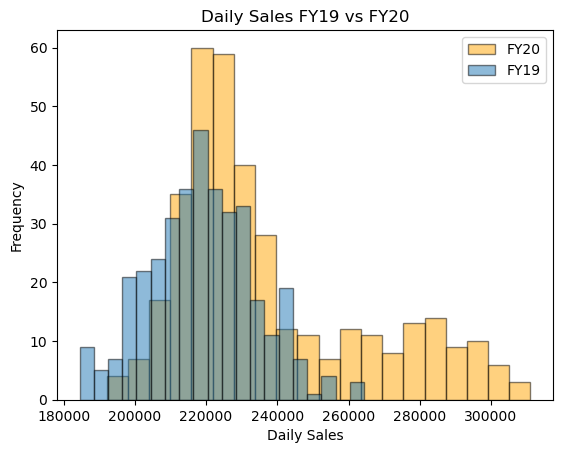

In [30]:
FY20_daily.plot.hist(bins=20, edgecolor='k', color='orange', alpha=0.5, label='FY20')
FY19_daily.plot.hist(bins=20, edgecolor='k', alpha=0.5, label='FY19')
plt.title('Daily Sales FY19 vs FY20')
plt.xlabel('Daily Sales')
plt.legend()
plt.show()

## Question 11

Looking at the summary, the CEO says the sales don't look that different. 

**(11)** Is the difference in sales statistically significant enough to justify increased bonuses? (Answer using inference, either a significance test or comparison of confidence intervals)

**Answer:** The p-value of 3.14E-28 is a number smaller than the significance level of 0.05, indicating there is convincing evidence against the null hypothesis. The data supoprts that the mean daily sales in FY 2020 is greater than in FY 2019. 

Performing a t-test to determine if there is a difference between the sample means of FY 2019 and FY 2020 daily sales with a significance level $\alpha$ = .05.

Hypotheses:

**H<sub>0</sub>**: There is no difference in the FY 2019 and FY 2020 sales 

**H<sub>a</sub>**: The mean daily sales in FY 2020 is greater than the mean daily sales in FY 2019

In [31]:
from scipy import stats

In [32]:
stats.ttest_ind(FY20_daily,FY19_daily, equal_var=False)

TtestResult(statistic=11.63815231954758, pvalue=3.1466556982150907e-28, df=568.5543653965846)